In [3]:
#calling important libraries

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [26]:
epma2 = pd.read_excel('/content/dataset epma preprocessed1.xlsx',
                      sheet_name='Sheet1')
epma2.dtypes

epma2['T'] = epma2['T'].astype(float)

In [27]:
#for splitting the dataframes

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# for calling the models

from sklearn.ensemble import GradientBoostingClassifier


#for calling the model performance metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [28]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target label (y)

# Defining the dataframe into X features and y target label

X = epma2.drop(columns=['T'])
y = epma2['T']



# Split into training and testing sets in a stratified manner

#for splitting the dataframes

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,

                                                    stratify=y, #applying stratified splitting to ensure proportional representation of target classes in training and test sets.

                                                    random_state=42)


# Check the distribution of target labels in the train and test sets
train_distribution = y_train.value_counts(normalize=True)

test_distribution = y_test.value_counts(normalize=True)

train_distribution, test_distribution

(T
 2.0    0.440120
 1.0    0.383234
 3.0    0.176647
 Name: proportion, dtype: float64,
 T
 2.0    0.440476
 1.0    0.380952
 3.0    0.178571
 Name: proportion, dtype: float64)

In [9]:
# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [10]:
# Function to train and evaluate the model

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):

    # Initialize the Gradient Boosting Classifier

    gb_model = GradientBoostingClassifier(random_state=42)

    gb_model.fit(X_train_fold, y_train_fold)

    y_val_pred = gb_model.predict(X_val_fold)

    accuracy = accuracy_score(y_val_fold, y_val_pred)

    return accuracy, gb_model

In [11]:
# Store fold metrics
fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': []
}
best_model = None
best_accuracy = 0

In [12]:
# Cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Validate additional metrics
    y_val_pred = model.predict(X_val_fold)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

Fold 1 Metrics:
  Accuracy: 0.7015
  Precision: 0.6920
  Recall: 0.7015
  F1-Score: 0.6900
Fold 2 Metrics:
  Accuracy: 0.7463
  Precision: 0.7419
  Recall: 0.7463
  F1-Score: 0.7375
Fold 3 Metrics:
  Accuracy: 0.6866
  Precision: 0.7018
  Recall: 0.6866
  F1-Score: 0.6687
Fold 4 Metrics:
  Accuracy: 0.7910
  Precision: 0.8076
  Recall: 0.7910
  F1-Score: 0.7879
Fold 5 Metrics:
  Accuracy: 0.7121
  Precision: 0.6981
  Recall: 0.7121
  F1-Score: 0.7012


In [13]:
# Average Metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")



Average Metrics Across All Folds:
  Accuracy: 0.7275
  Precision: 0.7283
  Recall: 0.7275
  F1-Score: 0.7170


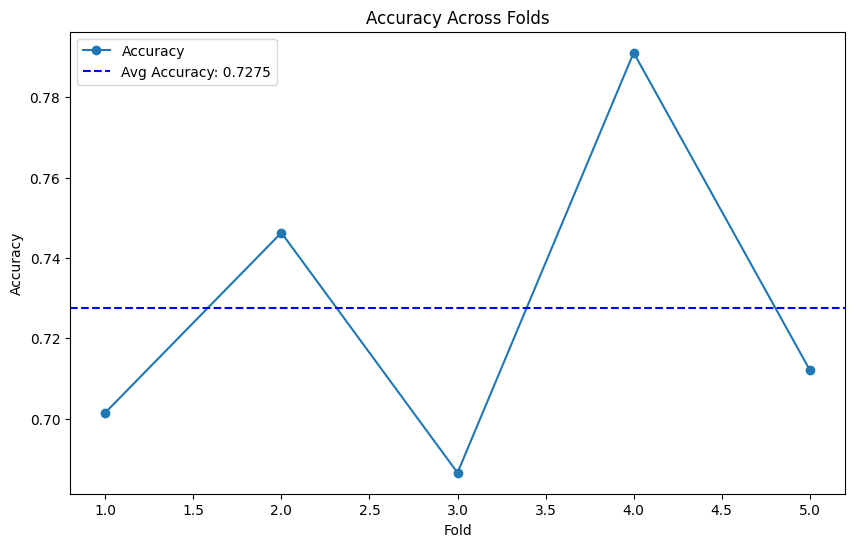

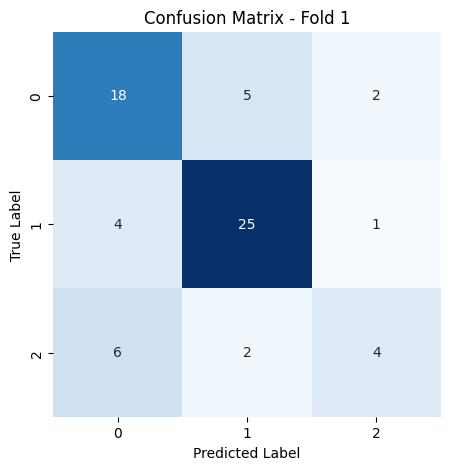

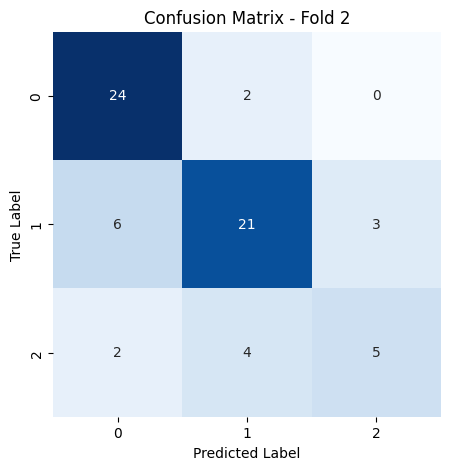

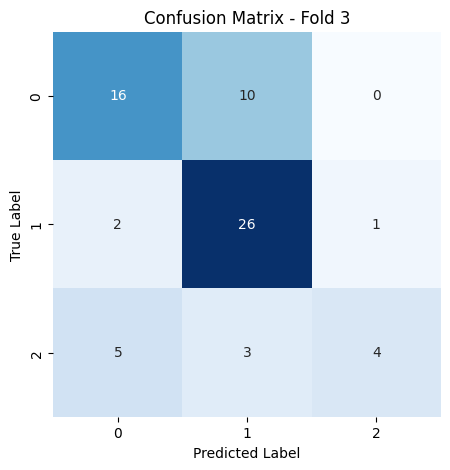

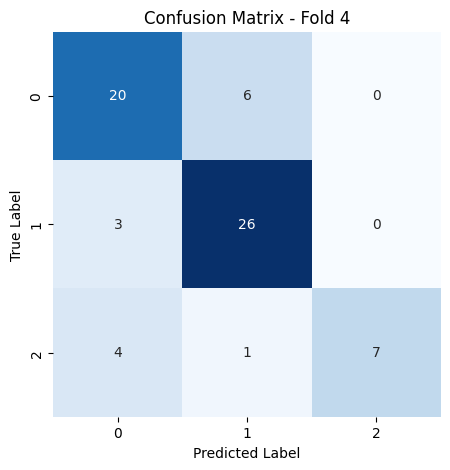

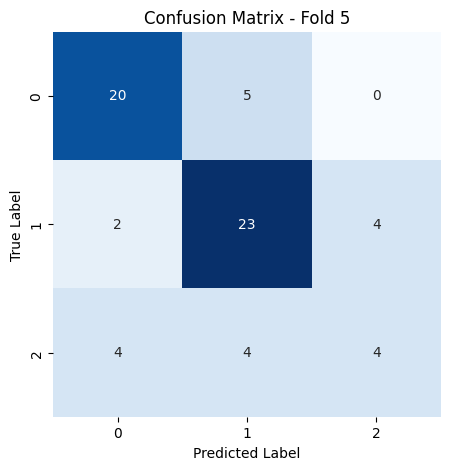

In [14]:
# Plot Metrics
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across Folds')
plt.legend()
plt.show()

# Confusion Matrix Visualization
for fold, confusion in enumerate(fold_metrics['confusion_matrices'], start=1):
    plt.figure(figsize=(5, 5))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()






Test Set Metrics:
  Accuracy: 0.7143
  Precision: 0.7137
  Recall: 0.7143
  F1-Score: 0.7133


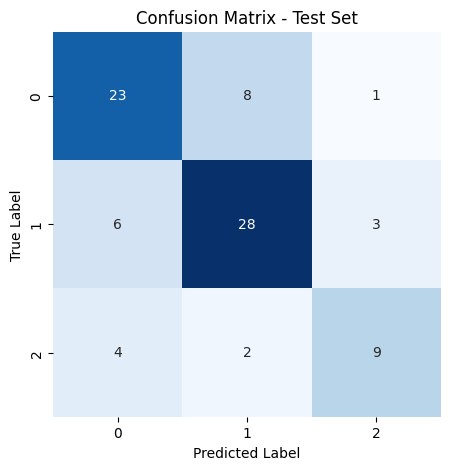

In [15]:
# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

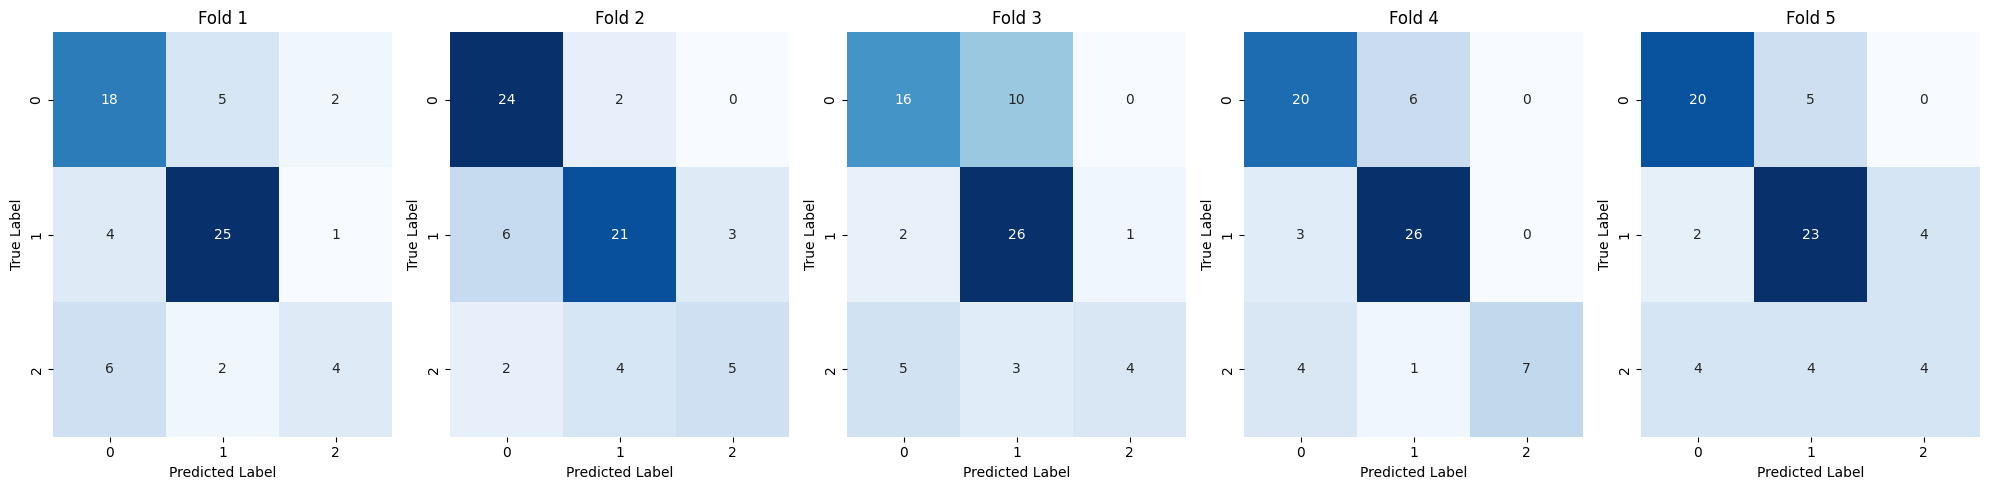

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion Matrix Visualization as Subplots
fig, axes = plt.subplots(1, len(fold_metrics['confusion_matrices']), figsize=(20, 5))

for fold, (confusion, ax) in enumerate(zip(fold_metrics['confusion_matrices'], axes), start=1):

    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

    ax.set_title(f'Fold {fold}')

    ax.set_xlabel('Predicted Label')

    ax.set_ylabel('True Label')

plt.tight_layout()

plt.show()

Fold 1 Metrics:
  Accuracy: 0.7692
  Precision: 0.7991
  Recall: 0.7692
  F1-Score: 0.7405
Fold 2 Metrics:
  Accuracy: 0.7692
  Precision: 0.7971
  Recall: 0.7692
  F1-Score: 0.7700
Fold 3 Metrics:
  Accuracy: 0.6154
  Precision: 0.6072
  Recall: 0.6154
  F1-Score: 0.6099
Fold 4 Metrics:
  Accuracy: 0.8462
  Precision: 0.8590
  Recall: 0.8462
  F1-Score: 0.8368
Fold 5 Metrics:
  Accuracy: 0.6154
  Precision: 0.6013
  Recall: 0.6154
  F1-Score: 0.5934
Fold 6 Metrics:
  Accuracy: 0.8077
  Precision: 0.8678
  Recall: 0.8077
  F1-Score: 0.7965
Fold 7 Metrics:
  Accuracy: 0.6538
  Precision: 0.6566
  Recall: 0.6538
  F1-Score: 0.6437


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 8 Metrics:
  Accuracy: 0.5769
  Precision: 0.4688
  Recall: 0.5769
  F1-Score: 0.5128
Fold 9 Metrics:
  Accuracy: 0.8462
  Precision: 0.8596
  Recall: 0.8462
  F1-Score: 0.8474
Fold 10 Metrics:
  Accuracy: 0.6000
  Precision: 0.6000
  Recall: 0.6000
  F1-Score: 0.6000
Fold 11 Metrics:
  Accuracy: 0.7200
  Precision: 0.7591
  Recall: 0.7200
  F1-Score: 0.7106
Fold 12 Metrics:
  Accuracy: 0.6800
  Precision: 0.7162
  Recall: 0.6800
  F1-Score: 0.6844
Fold 13 Metrics:
  Accuracy: 0.7600
  Precision: 0.7568
  Recall: 0.7600
  F1-Score: 0.7387

Average Metrics Across All Folds:
  Accuracy: 0.7123
  Precision: 0.7191
  Recall: 0.7123
  F1-Score: 0.6988


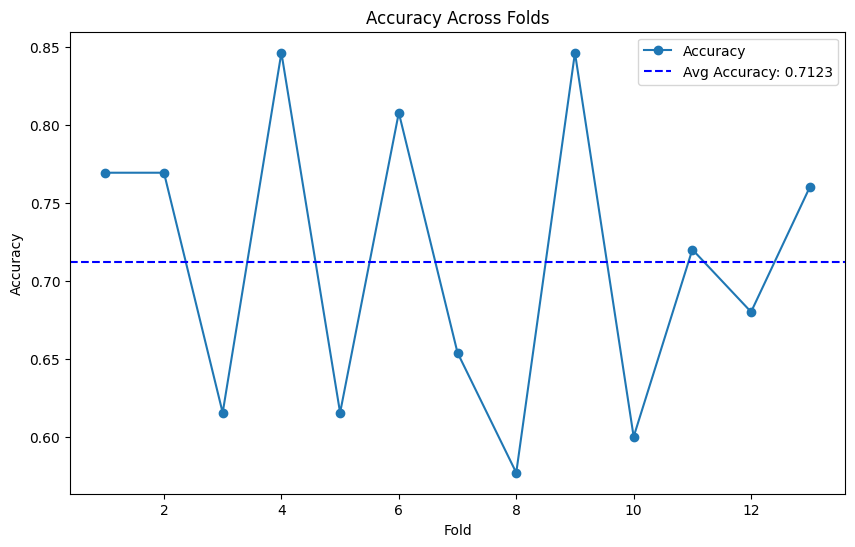

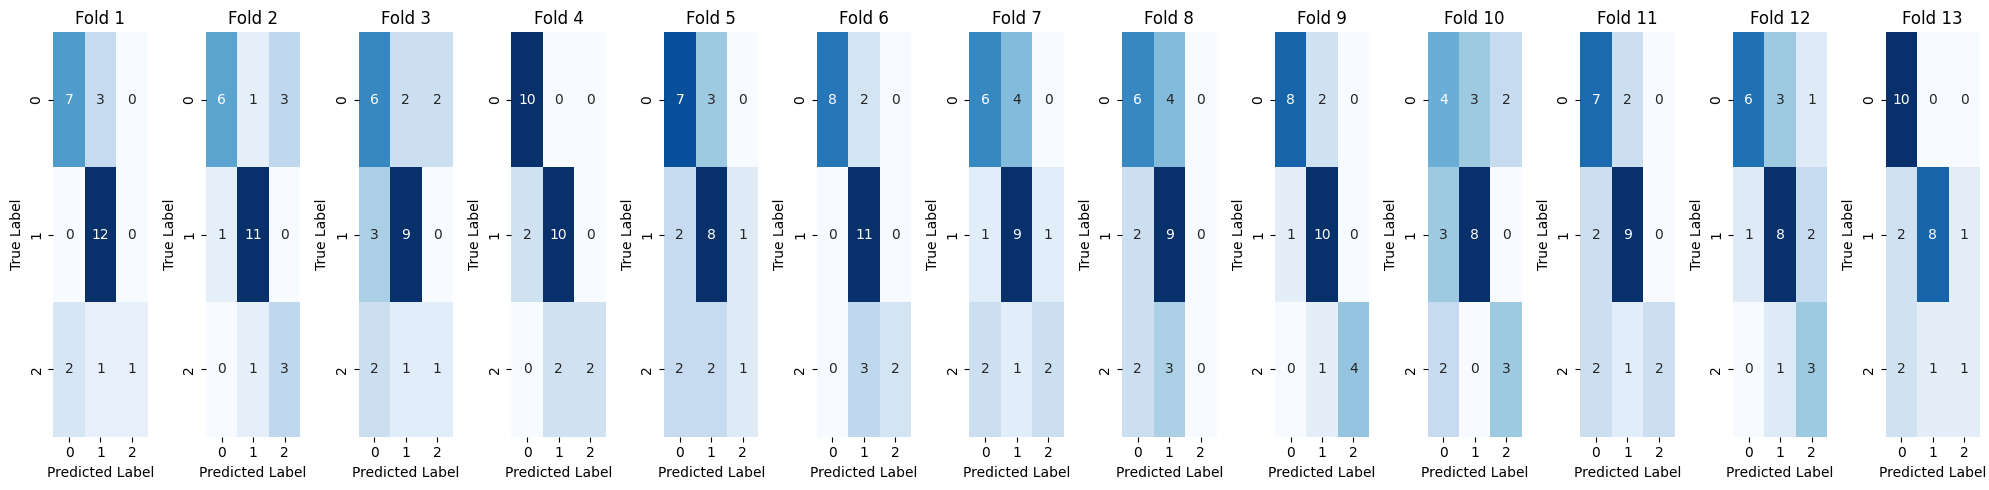


Test Set Metrics:
  Accuracy: 0.7143
  Precision: 0.7140
  Recall: 0.7143
  F1-Score: 0.7118


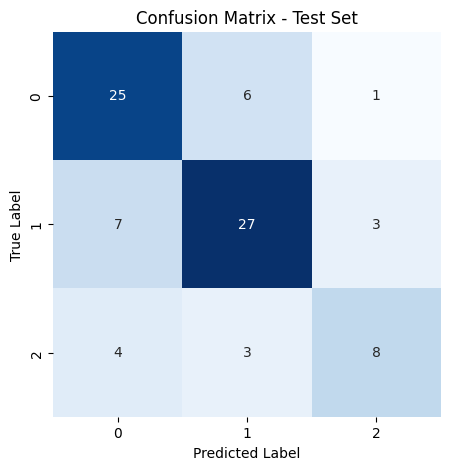

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Splitting the dataset
X = epma2.drop(columns=['T'])
y = epma2['T']

# Stratified split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=13, shuffle=True, random_state=42)

# Function to train and evaluate the model
def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    # Initialize the Gradient Boosting Classifier
    gb_model = GradientBoostingClassifier(random_state=42)

    gb_model.fit(X_train_fold, y_train_fold)

    y_val_pred = gb_model.predict(X_val_fold)

    accuracy = accuracy_score(y_val_fold, y_val_pred)

    return accuracy, gb_model

# Store fold metrics
fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': []
}
best_model = None
best_accuracy = 0

# Cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Validate additional metrics
    y_val_pred = model.predict(X_val_fold)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# Average Metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")

# Save the best model
joblib.dump(best_model, 'best_gradient_boosting_model.pkl')

# Plot Metrics
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across Folds')
plt.legend()
plt.show()

# Confusion Matrix Visualization as Subplots
fig, axes = plt.subplots(1, len(fold_metrics['confusion_matrices']), figsize=(20, 5))
for fold, (confusion, ax) in enumerate(zip(fold_metrics['confusion_matrices'], axes), start=1):
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Fold {fold}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Fold 1 Metrics:
  Accuracy: 0.7015
  Precision: 0.6920
  Recall: 0.7015
  F1-Score: 0.6900
Fold 2 Metrics:
  Accuracy: 0.7463
  Precision: 0.7419
  Recall: 0.7463
  F1-Score: 0.7375
Fold 3 Metrics:
  Accuracy: 0.6866
  Precision: 0.7018
  Recall: 0.6866
  F1-Score: 0.6687
Fold 4 Metrics:
  Accuracy: 0.7910
  Precision: 0.8076
  Recall: 0.7910
  F1-Score: 0.7879
Fold 5 Metrics:
  Accuracy: 0.7121
  Precision: 0.6981
  Recall: 0.7121
  F1-Score: 0.7012

Average Metrics Across All Folds:
  Accuracy: 0.7275
  Precision: 0.7283
  Recall: 0.7275
  F1-Score: 0.7170


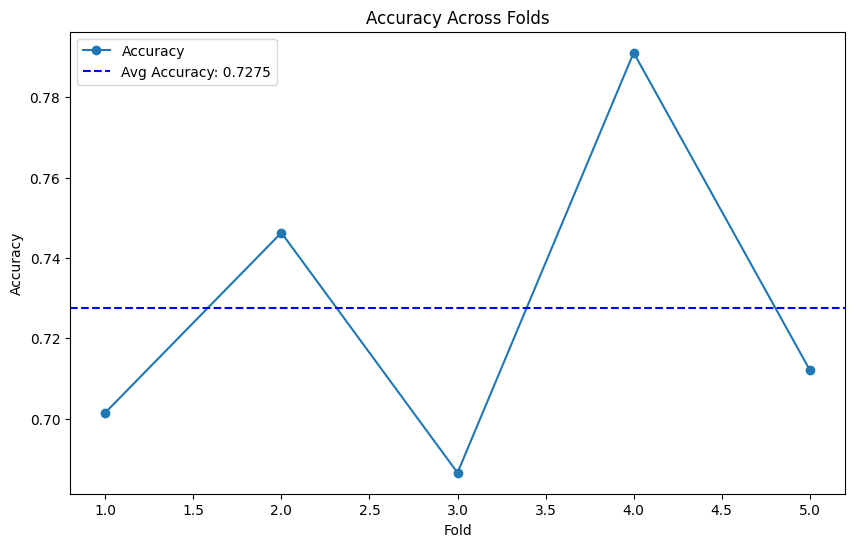

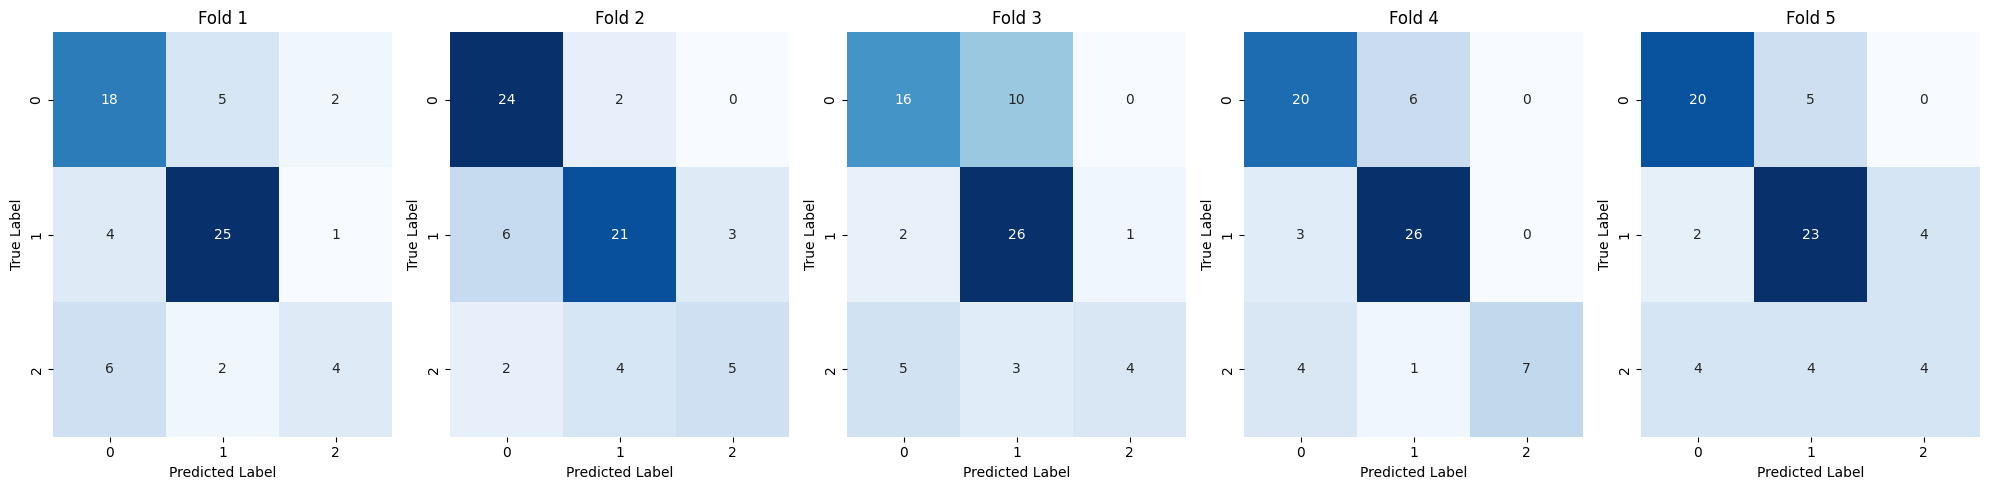


Test Set Metrics:
  Accuracy: 0.7143
  Precision: 0.7137
  Recall: 0.7143
  F1-Score: 0.7133


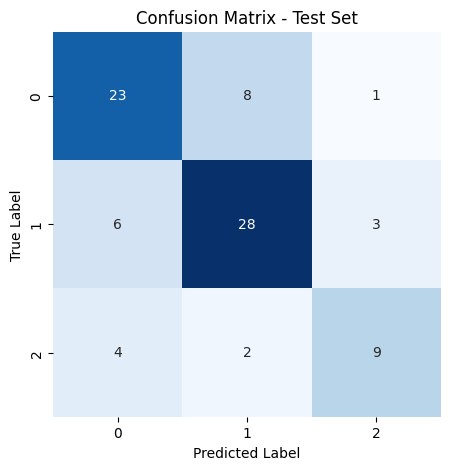

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Splitting the dataset
X = epma2.drop(columns=['T'])
y = epma2['T']

# Stratified split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Function to train and evaluate the model
def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    # Initialize the Gradient Boosting Classifier
    gb_model = GradientBoostingClassifier(random_state=42)

    gb_model.fit(X_train_fold, y_train_fold)

    y_val_pred = gb_model.predict(X_val_fold)

    accuracy = accuracy_score(y_val_fold, y_val_pred)

    return accuracy, gb_model

# Store fold metrics
fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': [],
    'roc_curves': [],
    'auc_scores': []
}
best_model = None
best_accuracy = 0

# Cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Validate additional metrics
    y_val_pred = model.predict(X_val_fold)
    y_val_prob = model.predict_proba(X_val_fold)[:, 1] if len(model.classes_) == 2 else None
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    if y_val_prob is not None:
        fpr, tpr, _ = roc_curve(y_val_fold, y_val_prob)
        auc_score = roc_auc_score(y_val_fold, y_val_prob)
        fold_metrics['roc_curves'].append((fpr, tpr))
        fold_metrics['auc_scores'].append(auc_score)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    if y_val_prob is not None:
        print(f"  AUC Score: {auc_score:.4f}")

# Average Metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])
avg_auc_score = np.mean(fold_metrics['auc_scores']) if fold_metrics['auc_scores'] else None

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")
if avg_auc_score is not None:
    print(f"  Average AUC Score: {avg_auc_score:.4f}")

# Save the best model
joblib.dump(best_model, 'best_gradient_boosting_model.pkl')

# Plot Metrics
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across Folds')
plt.legend()
plt.show()

# Confusion Matrix Visualization as Subplots
fig, axes = plt.subplots(1, len(fold_metrics['confusion_matrices']), figsize=(20, 5))
for fold, (confusion, ax) in enumerate(zip(fold_metrics['confusion_matrices'], axes), start=1):
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Fold {fold}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

# ROC Curve Visualization
if fold_metrics['roc_curves']:
    plt.figure(figsize=(10, 6))
    for fold, (fpr, tpr) in enumerate(fold_metrics['roc_curves'], start=1):
        plt.plot(fpr, tpr, label=f'Fold {fold} (AUC = {fold_metrics["auc_scores"][fold - 1]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Across Folds')
    plt.legend()
    plt.show()

# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
y_test_prob = best_model.predict_proba(X_test)[:, 1] if len(best_model.classes_) == 2 else None
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

test_auc = roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else None

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
if test_auc is not None:
    print(f"  AUC Score: {test_auc:.4f}")

# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Test ROC Curve
if y_test_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, label=f'Test ROC Curve (AUC = {test_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Test ROC Curve')
    plt.legend()
    plt.show()



Test Set Metrics:
  Accuracy: 0.6310
  Precision: 0.7088
  Recall: 0.6310
  F1-Score: 0.5998


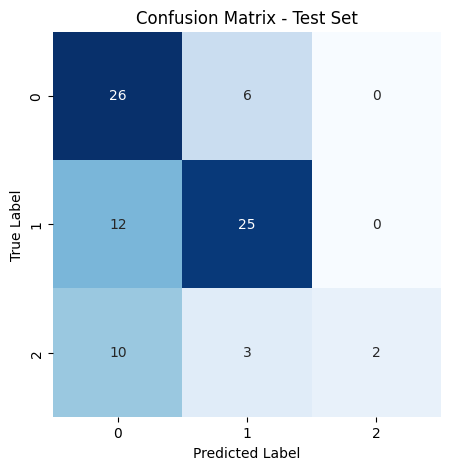

In [30]:


# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
y_test_prob = best_model.predict_proba(X_test)[:, 1] if len(best_model.classes_) == 2 else None
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

test_auc = roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else None

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
if test_auc is not None:
    print(f"  AUC Score: {test_auc:.4f}")

# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



#**Support vector machines**


In [ ]:
epma2.dtypes

Fold 1 Metrics:
  Accuracy: 0.7463
  Precision: 0.7558
  Recall: 0.7463
  F1-Score: 0.7312
Fold 2 Metrics:
  Accuracy: 0.6866
  Precision: 0.6730
  Recall: 0.6866
  F1-Score: 0.6728
Fold 3 Metrics:
  Accuracy: 0.6269
  Precision: 0.6325
  Recall: 0.6269
  F1-Score: 0.5942
Fold 4 Metrics:
  Accuracy: 0.7612
  Precision: 0.7677
  Recall: 0.7612
  F1-Score: 0.7445
Fold 5 Metrics:
  Accuracy: 0.6515
  Precision: 0.6269
  Recall: 0.6515
  F1-Score: 0.6300

Average Metrics Across All Folds:
  Accuracy: 0.6945
  Precision: 0.6912
  Recall: 0.6945
  F1-Score: 0.6745

Test Set Metrics:
  Accuracy: 0.6310
  Precision: 0.7088
  Recall: 0.6310
  F1-Score: 0.5998


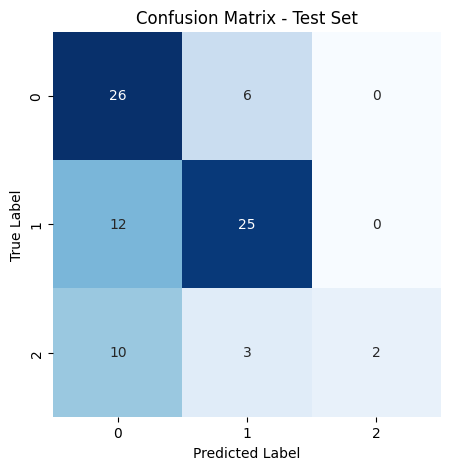

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Dataset preparation
# Assuming epma2_df is already loaded
X = epma2.drop(columns=['T'])  # Drop target and non-feature columns
y = epma2['T']



# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):

    # Initialize the SVM Classifier
    svm_model = SVC(kernel='rbf', probability=True, random_state=42)

    # Fit the model
    svm_model.fit(X_train_fold, y_train_fold)

    # Predict on validation set
    y_val_pred = svm_model.predict(X_val_fold)

    # Calculate accuracy
    accuracy = accuracy_score(y_val_fold, y_val_pred)

    return accuracy, svm_model

# Cross-validation
fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': [],
    'roc_curves': [],
    'auc_scores': []
}

best_model = None
best_accuracy = 0

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Validate additional metrics
    y_val_pred = model.predict(X_val_fold)
    y_val_prob = model.predict_proba(X_val_fold)[:, 1] if len(model.classes_) == 2 else None
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    if y_val_prob is not None:
        fpr, tpr, _ = roc_curve(y_val_fold, y_val_prob)
        auc_score = roc_auc_score(y_val_fold, y_val_prob)
        fold_metrics['roc_curves'].append((fpr, tpr))
        fold_metrics['auc_scores'].append(auc_score)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    if y_val_prob is not None:
        print(f"  AUC Score: {auc_score:.4f}")

# Average Metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])
avg_auc_score = np.mean(fold_metrics['auc_scores']) if fold_metrics['auc_scores'] else None

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")
if avg_auc_score is not None:
    print(f"  Average AUC Score: {avg_auc_score:.4f}")



# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
y_test_prob = best_model.predict_proba(X_test)[:, 1] if len(best_model.classes_) == 2 else None
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

test_auc = roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else None

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
if test_auc is not None:
    print(f"  AUC Score: {test_auc:.4f}")

# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Test ROC Curve
if y_test_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, label=f'Test ROC Curve (AUC = {test_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Test ROC Curve')
    plt.legend()
    plt.show()

